# 0 - Instalación de dependencias.






In [19]:
# Instalación sugerida en Google Colab si falta alguna librería.
!pip install -r requirements.txt

import os
from dotenv import load_dotenv
from typing import TypedDict
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
import re
from langgraph.graph import StateGraph, START, END
from typing import TypedDict


load_dotenv()


OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)
parser = StrOutputParser()

# 1 - Estructura del agente

In [20]:
class EstadoBasico(TypedDict):
    """
    Estado compartido del grafo.

    En LangGraph, el estado es la estructura de datos que viaja entre nodos.
    Cada nodo recibe este estado, lo procesa y devuelve cambios parciales.

    """
    mensaje_usuario: str
    intencion: str
    categoria_mueble: str
    presupuesto: int
    espacio_disponible: str
    necesita_asesoria: bool
    respuesta_final: str

# 2 - Creación de nodos a utilizar

In [21]:
def nodo_clasificador(state: EstadoBasico) -> EstadoBasico:
    prompt = ChatPromptTemplate.from_template("""
Eres un asistente de Falabella especializado en muebles.

Clasifica la intención del usuario en una de las siguientes opciones:

- buscar_mueble
- comparar_muebles
- consulta_medidas
- asesoria_decoracion
- fuera_de_alcance

Mensaje:
{mensaje}

Responde únicamente con una opción.
""")

    chain = prompt | llm | parser

    intencion = chain.invoke({
        "mensaje": state["mensaje_usuario"]
    }).strip().lower()

    state["intencion"] = intencion

    return state

import re

def extraer_preferencias(state: EstadoBasico) -> EstadoBasico:
    mensaje = state["mensaje_usuario"].lower()

    # Detectar categoría
    categorias = ["sofá", "sofa", "mesa", "rack", "silla", "comedor", "cama", "escritorio"]

    categoria = ""
    for c in categorias:
        if c in mensaje:
            categoria = "sofá" if c == "sofa" else c
            break

    # Si no menciona categoría, elegir una opción genérica para living pequeño
    if categoria == "":
        if "living" in mensaje:
            categoria = "rack"
        else:
            categoria = "sin_categoria"

    # Detectar presupuesto
    numeros = re.findall(r"\d+", mensaje)
    presupuesto = int(numeros[0]) if numeros else 0

    # Detectar espacio
    if "living pequeño" in mensaje or "espacio pequeño" in mensaje:
        espacio = "living pequeño"
    elif "living grande" in mensaje or "espacio grande" in mensaje:
        espacio = "living grande"
    else:
        espacio = "no especificado"

    state["categoria_mueble"] = categoria
    state["presupuesto"] = presupuesto
    state["espacio_disponible"] = espacio

    if categoria == "sin_categoria" or presupuesto == 0:
        state["necesita_asesoria"] = True

    return state

def generar_recomendacion(state: EstadoBasico) -> EstadoBasico:
    categoria = state["categoria_mueble"]
    presupuesto = state["presupuesto"]
    espacio = state["espacio_disponible"]

    opciones = [
        mueble for mueble in MUEBLES_SIMULADOS
        if mueble["precio"] <= presupuesto
        and mueble["categoria"] == categoria
        and mueble["espacio"] == espacio
    ]

    if not opciones:
        state["necesita_asesoria"] = True
        state["respuesta_final"] = (
            f"No encontré muebles en la base personalizada para la categoría '{categoria}', "
            f"espacio '{espacio}' y presupuesto ${presupuesto}. "
            "Derivaré tu solicitud a un asesor especializado."
        )
        return state

    producto = opciones[0]

    state["respuesta_final"] = (
        f"Te recomiendo el producto '{producto['nombre']}'. "
        f"Pertenece a la categoría {producto['categoria']}, "
        f"está pensado para {producto['espacio']} y tiene un valor de ${producto['precio']}."
    )

    state["necesita_asesoria"] = False
    return state

def escalar_asesor(state: EstadoBasico) -> EstadoBasico:

    state["respuesta_final"] = """
Debido a las características de tu búsqueda,
te recomendamos continuar con la atención de un asesor especializado en muebles,
quien podrá ayudarte a encontrar la alternativa que mejor se adapte a tus necesidades.
"""

    return state


def fuera_de_alcance(state: EstadoBasico) -> EstadoBasico:

    state["respuesta_final"] = (
        "Por ahora solo puedo ayudarte con recomendaciones y consultas relacionadas con muebles. "
        "Por ejemplo, puedes preguntarme: 'Busco un sofá para un living pequeño con un presupuesto de 400 mil pesos'."
    )

    return state

# 3 - Funciones Condicionales para el flujo

In [22]:
def decidir_por_intencion(state: EstadoBasico) -> str:

    if state["intencion"] in [
        "buscar_mueble",
        "comparar_muebles",
        "consulta_medidas",
        "asesoria_decoracion"
    ]:
        return "extraer_preferencias"

    return "fuera_de_alcance"


def decidir_por_asesoria(state: EstadoBasico) -> str:

    if state["necesita_asesoria"]:
        return "escalar_asesor"

    return "fin"

# 4- Construcción del grafo

In [23]:
constructor = StateGraph(EstadoBasico)

constructor.add_node("nodo_clasificador", nodo_clasificador)
constructor.add_node("extraer_preferencias", extraer_preferencias)
constructor.add_node("generar_recomendacion", generar_recomendacion)
constructor.add_node("escalar_asesor", escalar_asesor)
constructor.add_node("fuera_de_alcance", fuera_de_alcance)

# Inicio del flujo
constructor.add_edge(START, "nodo_clasificador")

# Primera decisión
constructor.add_conditional_edges(
    "nodo_clasificador",
    decidir_por_intencion,
    {
        "extraer_preferencias": "extraer_preferencias",
        "fuera_de_alcance": "fuera_de_alcance"
    }
)

# Extraer información del usuario
constructor.add_edge(
    "extraer_preferencias",
    "generar_recomendacion"
)

# Segunda decisión
constructor.add_conditional_edges(
    "generar_recomendacion",
    decidir_por_asesoria,
    {
        "fin": END,
        "escalar_asesor": "escalar_asesor"
    }
)
# Fin de las rutas
constructor.add_edge("escalar_asesor", END)
constructor.add_edge("fuera_de_alcance", END)

agente = constructor.compile()

# 5- Ejecución del programa

In [24]:
def ejecutar_agente():

    mensaje = input("Ingrese su consulta: ")

    estado_inicial: EstadoBasico = {
        "mensaje_usuario": mensaje,
        "intencion": "",
        "categoria_mueble": "",
        "presupuesto": 0,
        "espacio_disponible": "",
        "necesita_asesoria": False,
        "respuesta_final": ""
    }

    resultado = agente.invoke(estado_inicial)

    print("\nMensaje del usuario:")
    print(mensaje)

    print("\nEstado final:")
    print(resultado)

    print("\nRespuesta final:")
    print(resultado["respuesta_final"])

# Mockup con BD simulada


In [28]:
MUEBLES_SIMULADOS = [
    {
        "categoria": "sofá",
        "nombre": "Sofá compacto 2 cuerpos",
        "precio": 89990,
        "espacio": "living pequeño"
    },
    {
        "categoria": "mesa",
        "nombre": "Mesa lateral pequeña",
        "precio": 39990,
        "espacio": "living pequeño"
    },
    {
        "categoria": "rack",
        "nombre": "Rack TV compacto",
        "precio": 79990,
        "espacio": "living pequeño"
    }
]

ejecutar_agente()

Ingrese su consulta: Necesito una cotizacion para un living pequeño, busco muebles y tengo un presupuesto de 80000 

Mensaje del usuario:
Necesito una cotizacion para un living pequeño, busco muebles y tengo un presupuesto de 80000 

Estado final:
{'mensaje_usuario': 'Necesito una cotizacion para un living pequeño, busco muebles y tengo un presupuesto de 80000 ', 'intencion': 'buscar_mueble', 'categoria_mueble': 'rack', 'presupuesto': 80000, 'espacio_disponible': 'living pequeño', 'necesita_asesoria': False, 'respuesta_final': "Te recomiendo el producto 'Rack TV compacto'. Pertenece a la categoría rack, está pensado para living pequeño y tiene un valor de $79990."}

Respuesta final:
Te recomiendo el producto 'Rack TV compacto'. Pertenece a la categoría rack, está pensado para living pequeño y tiene un valor de $79990.


#Analisis propuesto


El agente de compra de muebles busca mejorar la experiencia de los clientes mediante la automatización de consultas relacionadas con la búsqueda y selección de productos para el hogar. A partir de la necesidad expresada por el usuario, el sistema identifica la intención de compra, la categoría del mueble, el presupuesto disponible y el espacio donde será utilizado.

Con esta información, el agente es capaz de entregar recomendaciones personalizadas, orientando al cliente en la elección de un producto que se ajuste a sus necesidades.

Además, funciona como un intermediario entre el cliente y Falabella, permitiendo derivar la atención a un asesor humano.

Con ello, se busca brindar una atención más rápida, accesible y eficiente, disminuyendo los tiempos de espera y fortaleciendo la comunicación entre el cliente y la empresa.

# Relación con mapa de valor

Este agente se conecta con el mapa de valor al responder la necesidad principal del usuario, la cual consiste en comprar muebles para el hogar de manera más simple, rápida y eficiente.

El agente se encarga de recomendar muebles cuyas dimensiones y características se ajusten al presupuesto y al espacio disponible proporcionados por el cliente, contribuyendo así a facilitar los trabajos del cliente identificados en el mapa de valor.

Además, el agente contribuye a generar diversas alegrías para el usuario, tales como encontrar muebles cómodos y a buenos precios, ahorrar tiempo gracias a la rapidez de las recomendaciones y recibir recomendaciones personalizadas. De esta manera, el sistema apoya principalmente las etapas de búsqueda y selección de productos.

Por otra parte, el agente permite aliviar algunas de las frustraciones identificadas en el mapa de valor, como la falta de tiempo para realizar la compra, la dificultad para comparar productos y el miedo de adquirir un mueble que no se adapte correctamente a las dimensiones reales. En caso de no encontrar una alternativa adecuada, el propio agente es capaz de derivar la consulta a un asesor humano.

De esta forma, el agente actúa como un aliviador de frustraciones y un creador de alegrías, mejorando la experiencia del usuario y entregando una atención más eficiente, personalizada y orientada a las necesidades del cliente.

# Diagrama de decisión

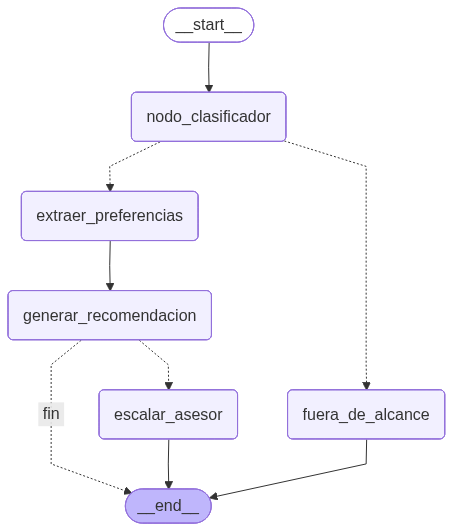

In [26]:
from IPython.display import Image, display

display(
    Image(
        agente.get_graph().draw_mermaid_png()
    )
)